# Notebook Introduction

Consider the Lotka-Volterra equations for a predator-prey dynamics:

$$
\begin{align}
& \dot x = \alpha x - \gamma xy \\
& \dot y = -\beta y + \eta (\gamma xy)
\end{align}
$$

Suppose we only know $\alpha, \beta$ and $\eta$, how can we approximate the term $\gamma xy$? In this case we will use and implement the *Universal Differential Equations* according to [1] in Python.

In particular, we will:
1. Generate a synthetic dataset by fixing the parameters first
2. Consider the L-V equations only with $\alpha, \beta, \eta$ known; the term $\gamma xy$ will be approximated with a Neural Network defined as $\texttt{NN}(\theta, t)$
3. Train the Neural Network with the method described in the paper, in particular using numerical integration of ODEs (Newton's first-order method) 

The loss used to train the NN will be the MSE loss, defined as 

$$
\mathcal L_{\texttt{MSE} }(\theta) := \frac{1}{N} \sum_{i = 1, \ldots, n} [(\hat x_\theta(t_i) - x_i)^2 + (\hat y_\theta(t_i) - y_i)^2]
$$

Where $\hat x_\theta, \hat y_\theta$ are the solutions of the following parametrised DE in a certain time interval $[0, T]$:

$$
\begin{align}
& \dot x = \alpha x - \texttt{NN}(\theta, t)[1] \\
& \dot y = -\beta y + \cdot \texttt{NN}(\theta, t)[0]
\end{align}
$$


> *Remark.* Our approach will differ from [1] as we will approximate the term $\gamma xy$ with *only one* neural network, instead of two. We consider this approach to be better and leverage our knowledge of the system further.

Moreover the neural network will have two inputs and two outputs, one for each component of the dynamical system.

In the end, we will compare the results with the ones presented in the paper.

In [1]:
# Libraries
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from torch import nn, optim 
import torch
from torchdiffeq import odeint
import pysindy as ps

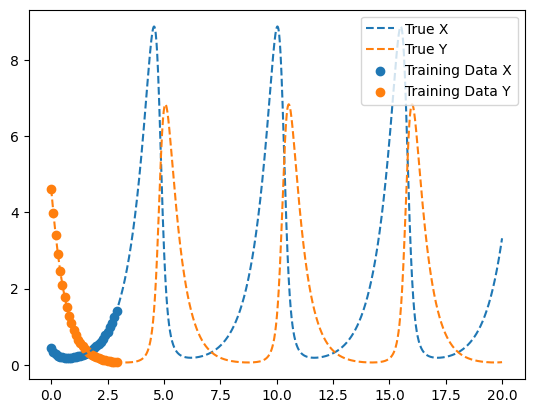

In [2]:
# Part 1: Synthetic Data Generation

alpha = 1.3
delta = 1.8
beta = 0.9
gamma = 0.8

def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.44249296, 4.6280594)

sol = solve_ivp(lotka_volterra, t_span = [0, 20], t_eval=np.arange(0, 20, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

plt.plot(T, X, "--", label="True X")
plt.plot(T, Y, "--", label="True Y")

T_train = T[:300:10]
X_train = X[:300:10]
Y_train = Y[:300:10]

plt.scatter(T_train, X_train, label="Training Data X")
plt.scatter(T_train, Y_train, label="Training Data Y")

plt.legend()

plt.show()




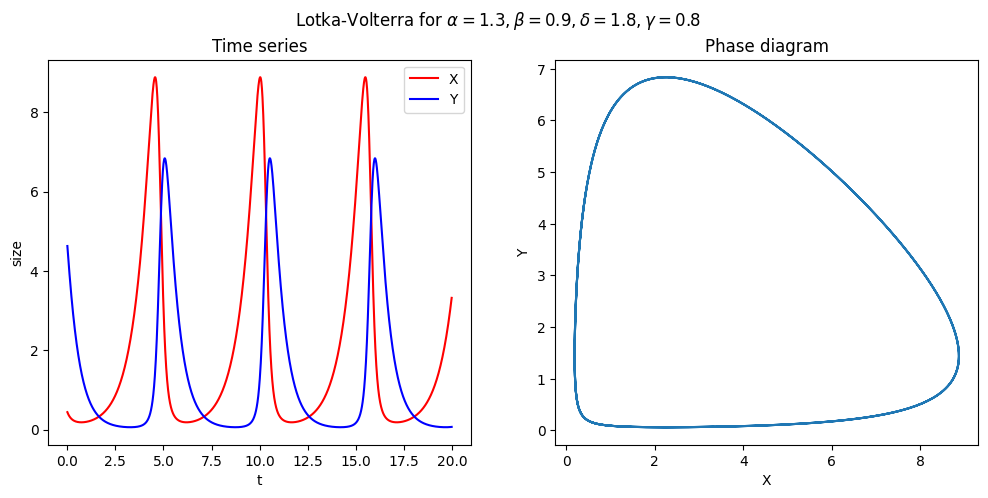

In [14]:
# Part 1: Synthetic Data Generation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax0 = axes[0]
ax1 = axes[1]

ax0.plot(T, X, label="X", color='red')
ax0.plot(T, Y, label="Y", color='blue')


ax0.legend()

ax0.set_xlabel("t")
ax0.set_ylabel("size")
ax0.set_title("Time series")

ax1.plot(X, Y)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title("Phase diagram")

fig.suptitle(fr"Lotka-Volterra for $\alpha={alpha}, \beta={beta}, \delta={delta}, \gamma={gamma}$")

plt.show()




In [3]:
# Define UDE

class universal_LV(nn.Module):
    def __init__(self, alpha, delta):
        super().__init__()
        self.alpha = alpha
        self.delta = delta
        
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 1), # We do 32 -> 1 -> 2 so the NN will try to learn beta, gamma implicitly!
            nn.Linear(1, 2)
        ) 

    def forward(self, t, data):
        out_net = self.net(data)
        x = data[0]
        y = data[1]

        summ = torch.tensor([self.alpha*x, -self.delta*y], dtype=torch.float32)

        out_net *= torch.tensor([-1, 1])

        return out_net + summ

In [4]:
my_lv = universal_LV(alpha, delta)

In [6]:
my_lv.load_state_dict(torch.load("./models_weights/my_lv_trained.eee"))

<All keys matched successfully>

In [512]:
# Train UDE network to training data
lr = 0.03
optimizer = torch.optim.Adam(my_lv.net.parameters(), lr)

for EPOCH in range(1, 1000):
    optimizer.zero_grad()
    my_lv.zero_grad()

    # get forward solution
    info = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), torch.tensor(T_train, dtype=torch.float32),
                  rtol=1e-7, atol=1e-7, method='dopri5')

    # calculate loss

    loss = torch.tensor([.0, .0])

    for i, (x, y) in enumerate(zip(X_train, Y_train)):
        data = torch.tensor([x, y], dtype=torch.float32)
        loss += torch.pow(
            info[i]-data,
            torch.tensor([2., 2.])
        )

    loss /= T_train.shape[0]

    loss_norm = loss.mean()

    loss_norm.backward()

    optimizer.step()

    print(f"EPOCH {EPOCH}, LOSS: {loss_norm}")



EPOCH 1, LOSS: 77.35200500488281
EPOCH 2, LOSS: 10.0615873336792
EPOCH 3, LOSS: 48.71004867553711
EPOCH 4, LOSS: 11.032272338867188
EPOCH 5, LOSS: 0.47057244181632996
EPOCH 6, LOSS: 0.47658243775367737
EPOCH 7, LOSS: 2.421884298324585
EPOCH 8, LOSS: 0.762167751789093
EPOCH 9, LOSS: 0.06339795142412186
EPOCH 10, LOSS: 0.030147969722747803
EPOCH 11, LOSS: 0.06255505234003067
EPOCH 12, LOSS: 0.08054625242948532
EPOCH 13, LOSS: 0.0881943553686142
EPOCH 14, LOSS: 0.09001634269952774
EPOCH 15, LOSS: 0.08840733021497726
EPOCH 16, LOSS: 0.08476261794567108
EPOCH 17, LOSS: 0.08000361174345016
EPOCH 18, LOSS: 0.07478252798318863
EPOCH 19, LOSS: 0.06957093626260757
EPOCH 20, LOSS: 0.06470496952533722
EPOCH 21, LOSS: 0.06041276827454567
EPOCH 22, LOSS: 0.05683314427733421
EPOCH 23, LOSS: 0.054029274731874466
EPOCH 24, LOSS: 0.051999978721141815
EPOCH 25, LOSS: 0.05069031938910484
EPOCH 26, LOSS: 0.05000164359807968
EPOCH 27, LOSS: 0.04980340972542763
EPOCH 28, LOSS: 0.04994545504450798
EPOCH 29, L

In [7]:
pred = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), torch.tensor(T_train, dtype=torch.float32))

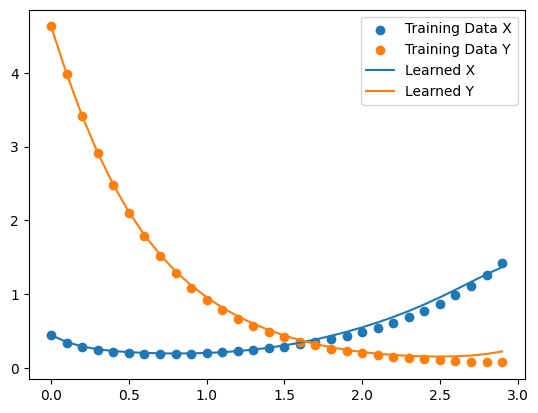

In [8]:
plt.scatter(T_train, X_train,label="Training Data X")
plt.scatter(T_train, Y_train,label="Training Data Y")

plt.plot(T_train, pred[:, 0].detach().numpy(), label="Learned X")
plt.plot(T_train, pred[:, 1].detach().numpy(), label="Learned Y")

plt.legend()

plt.show()


In [8]:
# try it with NDEs

class neural_LV(nn.Module):
    # other case: full NN approach
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16), 
            nn.LeakyReLU(),
            nn.Linear(16, 2)
        ) 

    def forward(self, t, data):
        return self.net(data)


In [ ]:

my_neural_lv = neural_LV()
my_neural_lv = my_neural_lv

from tqdm import tqdm 

lr = 0.005
n_optimizer = torch.optim.Adam(my_neural_lv.net.parameters(), lr)

x0_torch = torch.tensor(x0, dtype=torch.float32)
T_train_torch = torch.tensor(T_train, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train, dtype=torch.float32)
X_train_torch = torch.tensor(X_train, dtype=torch.float32)

for EPOCH in (range(1, 1000)):
    n_optimizer.zero_grad()

    # get forward solution
    info = odeint(my_neural_lv, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-5, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - torch.stack([X_train_torch, Y_train_torch], dim=1)), 2)**2
    loss_norm = loss_norm / T_train.shape[0]
    loss_norm.backward()

    n_optimizer.step()

    with torch.no_grad():
        
        print(f"Epoch {EPOCH}: MSE Loss (L2 norm)= {torch.norm(loss_norm, 2):.3E}")


Epoch 1: MSE Loss (L2 norm)= 8.504E+00
Epoch 2: MSE Loss (L2 norm)= 8.118E+00
Epoch 3: MSE Loss (L2 norm)= 7.622E+00
Epoch 4: MSE Loss (L2 norm)= 6.997E+00
Epoch 5: MSE Loss (L2 norm)= 6.178E+00
Epoch 6: MSE Loss (L2 norm)= 5.258E+00
Epoch 7: MSE Loss (L2 norm)= 4.275E+00
Epoch 8: MSE Loss (L2 norm)= 3.254E+00
Epoch 9: MSE Loss (L2 norm)= 2.254E+00
Epoch 10: MSE Loss (L2 norm)= 1.378E+00
Epoch 11: MSE Loss (L2 norm)= 7.317E-01
Epoch 12: MSE Loss (L2 norm)= 3.770E-01
Epoch 13: MSE Loss (L2 norm)= 2.943E-01
Epoch 14: MSE Loss (L2 norm)= 3.466E-01
Epoch 15: MSE Loss (L2 norm)= 3.946E-01
Epoch 16: MSE Loss (L2 norm)= 3.988E-01
Epoch 17: MSE Loss (L2 norm)= 3.755E-01
Epoch 18: MSE Loss (L2 norm)= 3.496E-01
Epoch 19: MSE Loss (L2 norm)= 3.361E-01
Epoch 20: MSE Loss (L2 norm)= 3.369E-01
Epoch 21: MSE Loss (L2 norm)= 3.462E-01
Epoch 22: MSE Loss (L2 norm)= 3.539E-01
Epoch 23: MSE Loss (L2 norm)= 3.526E-01
Epoch 24: MSE Loss (L2 norm)= 3.398E-01
Epoch 25: MSE Loss (L2 norm)= 3.172E-01
Epoch 26:

In [9]:
my_neural_lv = neural_LV()
my_neural_lv.load_state_dict(torch.load("./models_weights/my_lv_neural_trained.eee"))

<All keys matched successfully>

In [14]:
# What if we trained SINDy without UDE-enhanched derivatives

sol = solve_ivp(lotka_volterra, t_span = [0, 20], t_eval=np.arange(0, 20, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y

T = sol.t
X = data[0]
Y = data[1]

T_train_ps = T[:300:10]
X_train_ps = X[:300:10]
Y_train_ps = Y[:300:10]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    # x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

# Even by manipulating the STLSQ coefficient we won't be able to get rid of the quadratic and cubic term of the unneccessary coefficients

(x)' =  1.248 x +  0.124 x^2 + -0.885 x y + -0.066 x^3
(y)' = -1.800 y +  0.787 x y


In [15]:
# Train SINDy with the known derivatives now!

pred_new = odeint(my_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.001))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ(0.3)
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  1.064 x + -0.791 x y
(y)' = -1.949 y +  1.350 x y


In [16]:
# do the same thing with NDE
pred_new = odeint(my_neural_lv, torch.tensor(x0, dtype=torch.float32), teval:=torch.arange(0, 3, 0.001))
pred_new_np = pred_new.detach().numpy()

T_train_ps = teval.detach().numpy()
X_train_ps = pred_new_np[:, 0]
Y_train_ps = pred_new_np[:, 1]

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(10, include_interaction=True, include_bias=False),
    optimizer=ps.STLSQ()
)

X_dot = np.zeros((T_train_ps.shape[0], 2))

for i,(t,x, y) in enumerate(zip(T_train_ps, X_train_ps, Y_train_ps)):
    X_dot[i, :] = my_lv(
        torch.tensor([t], dtype=torch.float32),
        torch.tensor([x, y], dtype=torch.float32)
    ).detach().numpy()

model.fit(
    np.stack((X_train_ps, Y_train_ps), axis=-1),
    t = T_train_ps,
    x_dot=X_dot,
    feature_names=['x','y']
        )

model.print()

(x)' =  2.625 x + -0.306 y + -3.793 x^2 +  2.656 x^3 + -0.429 x^5
(y)' = -1.710 y +  0.279 x^2 +  0.491 x y


In [42]:
torch.save(my_lv.state_dict(), "./my_lv_trained.eee")
torch.save(my_neural_lv.state_dict(), "./my_lv_neural_trained.eee")

# to load: my_lv.load_state_dict(torch.load("..."))

In [38]:
# post structure parameter estimation to improve our obtained parameters

# basically just optimize the deduced functional form into what we know!

from scipy.optimize import minimize

def identified_lv(t, vars, alpha, beta, gamma, delta,):
    x, y = vars
    return np.array([
        alpha*x - beta*x*y,
        gamma*x*y - delta*y
    ])

# calculate loss to minimize
def loss_fn(params):
    alpha, beta, gamma, delta = params
    
    # solve the current lv
    sol = solve_ivp(
        identified_lv, 
        t_span=[T_train[0], T_train[-1]], 
        t_eval=T_train,
        args=(alpha, beta, gamma, delta),
        y0=x0,
        rtol=1e-9, atol=1e-9
    )

    pred_x = sol.y[0]
    pred_y = sol.y[1]
    
    error = np.sum((pred_x - X_train)**2) + np.sum((pred_y - Y_train)**2)
    return error

# optimize with initial guess from before!
x0_params = [1.254, 0.834, 0.636, 1.744]

result = minimize(loss_fn, x0_params)

print(result.x)

[1.30000148 0.90000097 0.80007929 1.8000203 ]


In [13]:
# plot my_lv.net(...)[0] vs -0.9xy on 3D (and on training data)

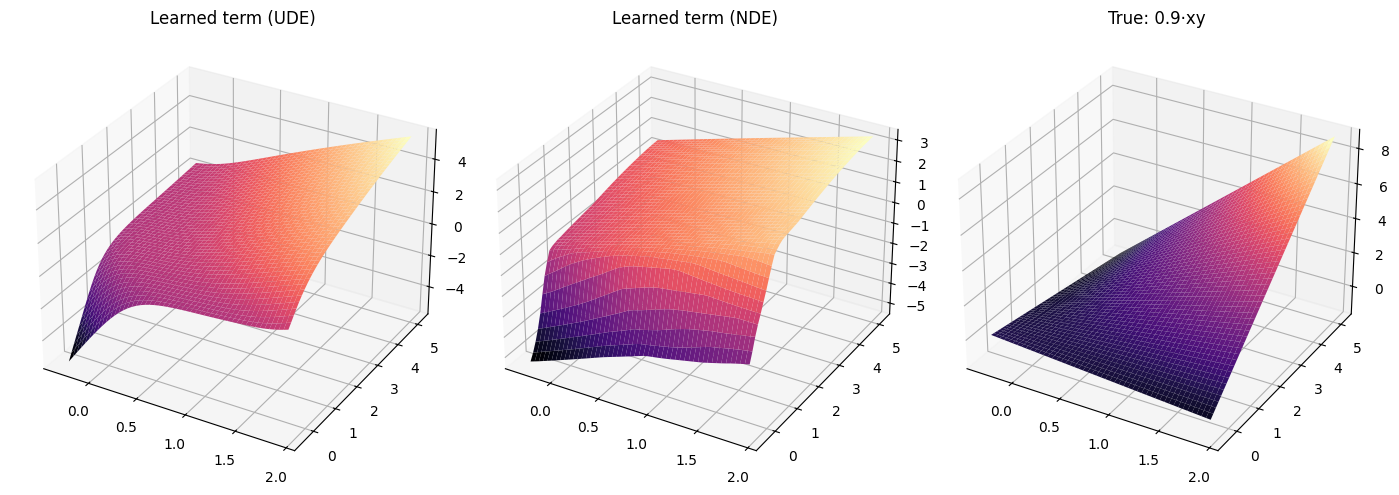

In [ ]:
x_min, x_max = X_train.min() - 0.5, X_train.max() + 0.5
y_min, y_max = Y_train.min() - 0.5, Y_train.max() + 0.5

x = np.linspace(x_min, x_max, 50)
y = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x, y)

# Feed grid through NN
punti_input = np.stack([X.ravel(), Y.ravel()], axis=-1)
input_tensor = torch.tensor(punti_input, dtype=torch.float32)

with torch.no_grad():
    z_pred = my_lv.net(input_tensor)[:, 0]  # Take first output
    Z_nn = z_pred.reshape(X.shape).numpy()
    z_ude_pred = my_neural_lv(0, input_tensor)[:, 0]
    Z_ude_nn = - z_ude_pred.reshape(X.shape).numpy() + alpha * X # transformation into what should be the beta * x * y term

# True function: -beta*x*y (where beta=0.9)
Z_true = 0.9 * X * Y

fig = plt.figure(figsize=(14, 5))

# Plot UDE
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_nn, cmap='magma', edgecolor='none')
ax1.set_title('Learned term (UDE)')

# Plot NDE 
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_ude_nn, cmap='magma', edgecolor='none')
ax2.set_title('Learned term (NDE)')

# Plot NDE 
ax2 = fig.add_subplot(133, projection='3d')
ax2.plot_surface(X, Y, Z_true, cmap='magma', edgecolor='none')
ax2.set_title('True: 0.9·xy')


plt.tight_layout()
plt.show()

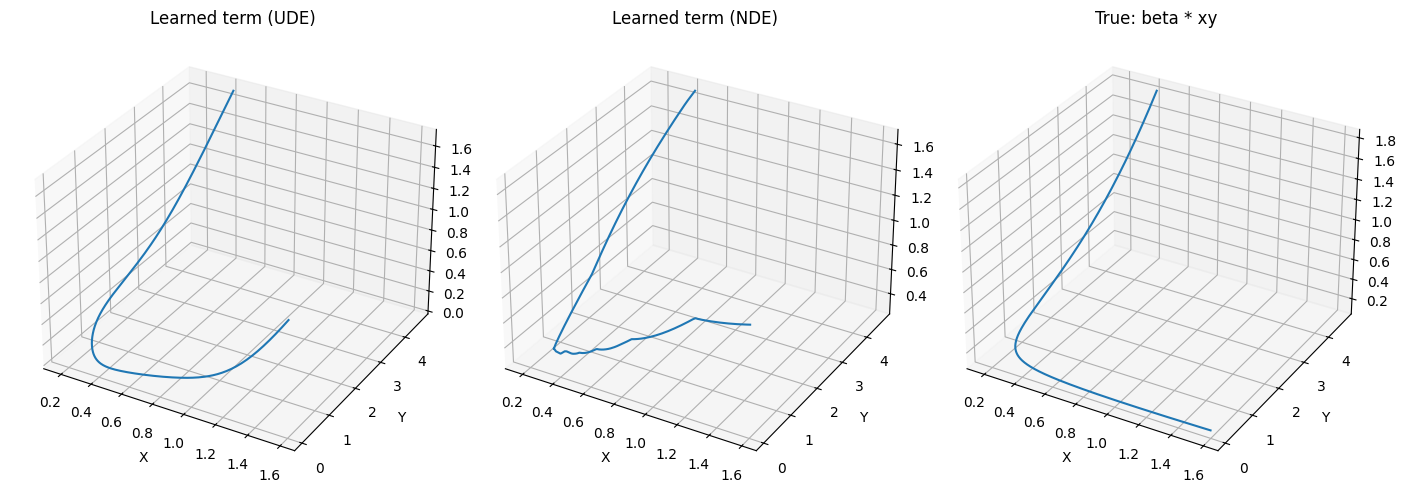

In [22]:
# Make plots
T_train = T[:300:1]
X_train = X[:300:1]
Y_train = Y[:300:1]


X_pts = X_train
Y_pts = Y_train

punti_input = np.stack([X_pts, Y_pts], axis=-1)
input_tensor = torch.tensor(punti_input, dtype=torch.float32)

with torch.no_grad():
    z_pred = my_lv.net(input_tensor).squeeze()
    Z_nn = z_pred.numpy()[:, 0]

    z_ude_pred = my_neural_lv(0, input_tensor)[:, 0]
    Z_ude_nn = -z_ude_pred.numpy() + 2 * X_pts   # extrapolate dynamics by applying some ad-hoc transformations

# True function
Z_true = beta * X_pts * Y_pts

fig = plt.figure(figsize=(14, 5))

# Plot UDE
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X_pts, Y_pts, Z_nn)
ax1.set_title('Learned term (UDE)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot NDE
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(X_pts, Y_pts, Z_ude_nn)
ax2.set_title('Learned term (NDE)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot true
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(X_pts, Y_pts, Z_true)
ax3.set_title('True: beta * xy')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')

plt.tight_layout()
plt.show()

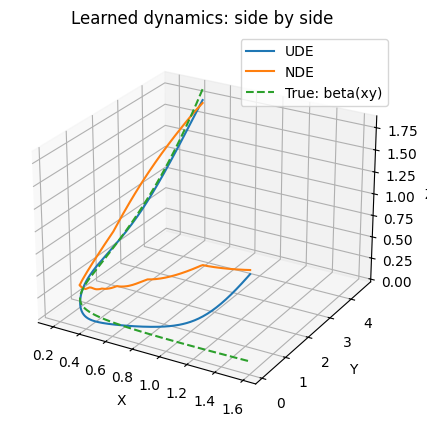

In [24]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_pts, Y_pts, Z_nn, label='UDE')
ax.plot(X_pts, Y_pts, Z_ude_nn, label='NDE')
ax.plot(X_pts, Y_pts, Z_true, "--", label='True: beta(xy)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=25, azim=-60)
ax.legend()

plt.title("Learned dynamics: side by side")
plt.show()

# References

[1] C. Rackauckas et al., ‘Universal Differential Equations for Scientific Machine Learning’, Aug. 31, 2020, In Review. doi: 10.21203/rs.3.rs-55125/v1.
